# インド株 ファクター検証 — Step 2: IC（Information Coefficient）

Step 1（分位分析）の続き。同じパネル・同じ規約で、シグナルとリターンの**相関そのもの**を見る。

## このノートの流れ

1. パネル構築（Step 1 と同一）
2. **IC の時系列** — 月次 IC、12ヶ月移動平均、累積 IC
3. **IC の減衰** — h = 1〜12 ヶ月先の単月リターンに対する IC

## IC の定義

時点 $t$ のクロスセクションで、スコア $x_{i,t}$ と先行リターン $r_{i,t \to t+h}$ の相関:

$$\mathrm{IC}_t^{(h)} = \mathrm{corr}\big(x_{i,t},\; r_{i,\,t+h-1 \to t+h}\big), \qquad i \in \mathcal{U}_t$$

- 既定は **Spearman（順位相関）**。外れ値・リターン分布の裾に頑健。
  順位相関は単調変換で不変なので、raw / z-score / Blom のどれで計算しても同じ値になる
- **Pearson** は値の距離を使うため変換に依存する。Blom スコアに対する Pearson は
  「両側を正規化した上での線形相関」で、実装上のアルファ合成に近い量
- 減衰は「$h$ ヶ月先の**単月**リターン」に対する IC。累積リターンではないので
  ホライズン間で系列が重複せず、$h$ ごとの寄与を独立に読める

$\mathrm{ICIR} = \overline{\mathrm{IC}} / \sigma(\mathrm{IC})$、年率換算は $\times\sqrt{12}$。
IC 系列は自己相関を持つことがあるため、有意性は Newey-West t 値で見る。

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import factorlab as fl

fl.plotting.set_style()
pd.set_option("display.width", 200, "display.max_columns", 60, "display.float_format", lambda v: f"{v:,.4f}")

# ---- Step 1 と同じ設定 -------------------------------------------------------
FACTOR = "bp_act"
FACTOR_LABEL = "B/P (bp_act)"
START, END = 200701, 202607
HORIZONS = list(range(1, 13))    # IC 減衰のホライズン（1〜12ヶ月先）
MA_WINDOW = 12                   # IC 時系列の移動平均窓

## 1. パネル構築

Step 1 と同じ `build_panel` に加え、`add_forward_returns` で
h = 1..12 ヶ月先の**単月**リターン列（`fwd_rtn_1` ... `fwd_rtn_12`）を付ける。
これらは `barra/rtn/{t}.pkl` の `lag == h` 行そのもの。

In [2]:
panel = fl.data.build_panel([FACTOR], start=START, end=END)
panel = fl.preprocess.standardize_panel(panel, FACTOR, method="blom")
panel = fl.data.add_forward_returns(panel, HORIZONS)

SCORE = f"{FACTOR}_blom"
print(panel.shape)
panel[[FACTOR, SCORE, "fwd_rtn", "fwd_rtn_1", "fwd_rtn_6", "fwd_rtn_12"]].head()

(85493, 24)


bp_act  bp_act_blom  fwd_rtn  fwd_rtn_1  fwd_rtn_6  fwd_rtn_12
yyyymm bid                                                                    
200701 INDAAC1  0.1854       0.1969  -0.0554    -0.0554     0.0996     -0.1023
       INDAAT1  0.1896       0.2470  -0.2050    -0.2050     0.1218     -0.1941
       INDAAV1  0.4596       1.2278  -0.2100    -0.2100     0.0612     -0.2369
       INDAAW1  0.0472      -1.8563  -0.1532    -0.1532     0.0962     -0.0232
       INDAAY1  0.1406      -0.3493  -0.0166    -0.0166     0.1276     -0.0664

In [3]:
# サニティチェック: fwd_rtn（lag=1）と fwd_rtn_1 は同一のはず
assert panel["fwd_rtn"].equals(panel["fwd_rtn_1"])
print("fwd_rtn == fwd_rtn_1 : OK")
print("各ホライズンの非欠損数:")
panel[[f"fwd_rtn_{h}" for h in HORIZONS]].count().to_frame("n_obs").T

fwd_rtn == fwd_rtn_1 : OK
各ホライズンの非欠損数:


,fwd_rtn_1,fwd_rtn_2,fwd_rtn_3,fwd_rtn_4,fwd_rtn_5,fwd_rtn_6,fwd_rtn_7,fwd_rtn_8,fwd_rtn_9,fwd_rtn_10,fwd_rtn_11,fwd_rtn_12
n_obs,84850,84201,83553,82888,82222,81555,80865,80174,79483,78770,78058,77346


## 2. IC の時系列

Spearman を主、Blom スコアに対する Pearson を従として併記する。

In [4]:
ic_spearman = fl.ic.information_coefficient(panel, SCORE, "fwd_rtn", method="spearman")
ic_pearson  = fl.ic.information_coefficient(panel, SCORE, "fwd_rtn", method="pearson")

summary = pd.DataFrame({
    "Spearman": fl.ic.ic_summary(ic_spearman),
    "Pearson (on Blom)": fl.ic.ic_summary(ic_pearson),
}).T
summary

,n_months,mean_IC,std_IC,ICIR,ICIR_ann,t_stat,t_stat_NW,hit_ratio,autocorr_1
Spearman,234.0000,-0.0168,0.1847,-0.0908,-0.3144,-1.3885,-1.3158,0.4316,0.0597
Pearson (on Blom),234.0000,-0.0023,0.1699,-0.0137,-0.0475,-0.2096,-0.2018,0.4786,0.0201


In [5]:
# 順位相関は単調変換で不変 -> raw / z-score / Blom で Spearman IC は一致する
ic_raw = fl.ic.information_coefficient(panel, FACTOR, "fwd_rtn", method="spearman")
print("Spearman IC (raw) == Spearman IC (Blom):",
      np.allclose(ic_raw.dropna(), ic_spearman.dropna()))

Spearman IC (raw) == Spearman IC (Blom): True


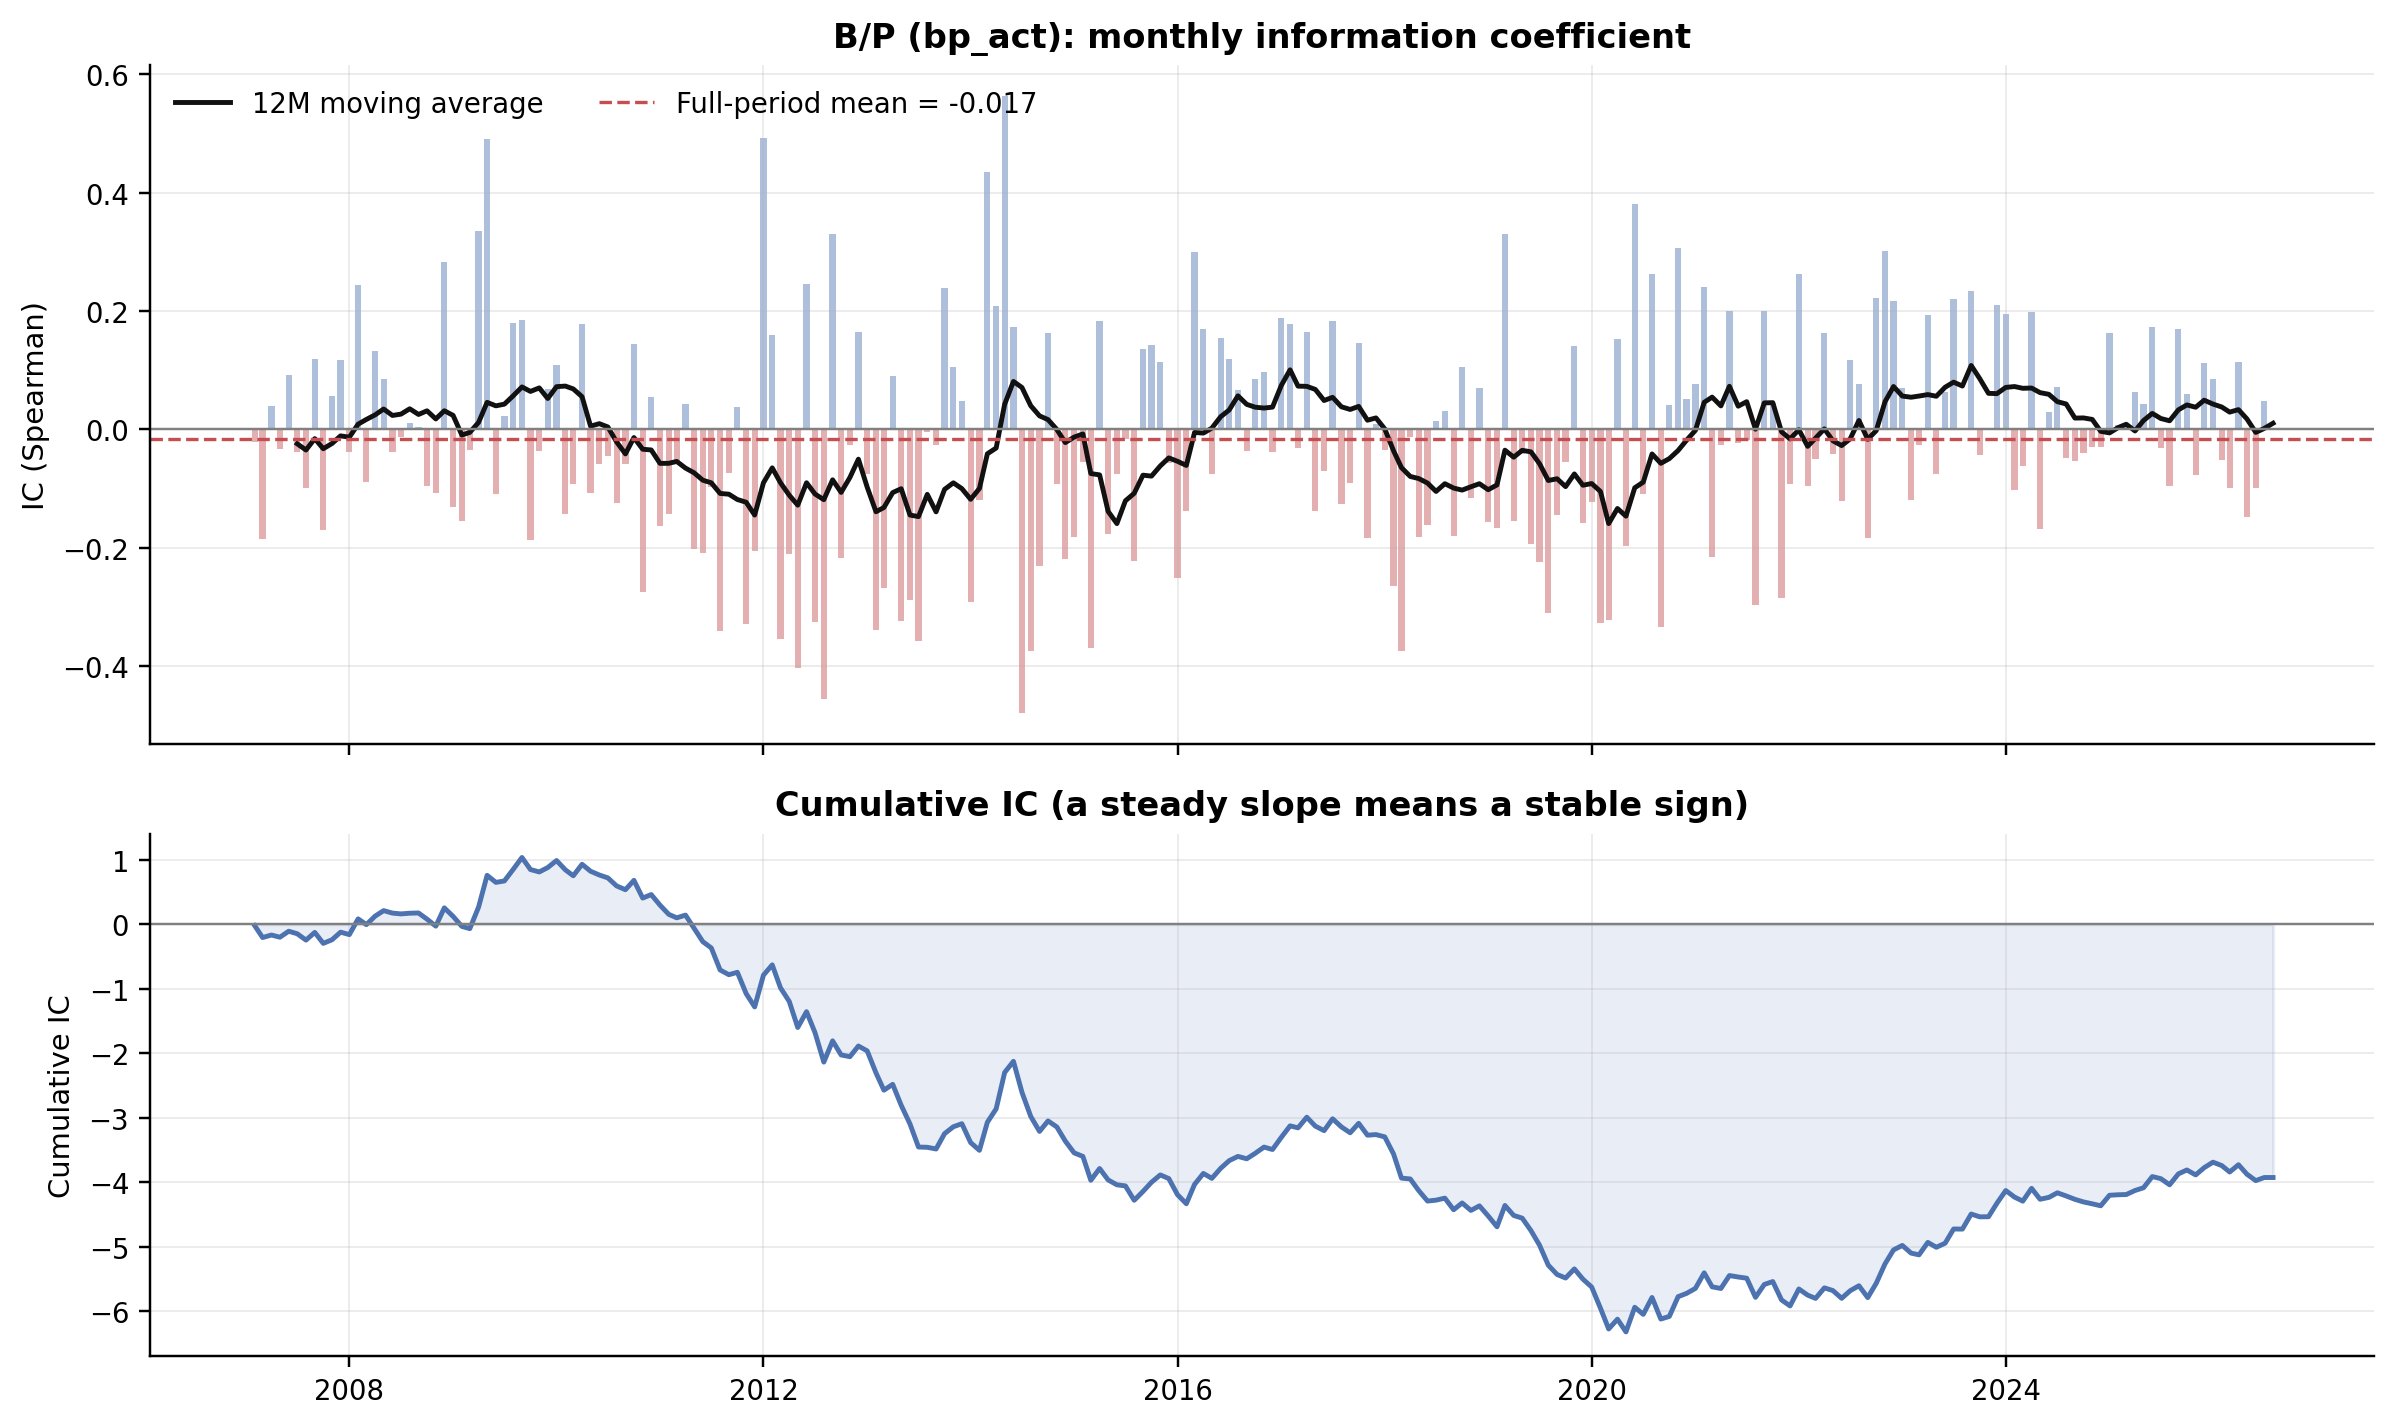

In [6]:
fig = fl.plotting.plot_ic(ic_spearman, ma_window=MA_WINDOW, factor=FACTOR_LABEL, method="Spearman")
fl.plotting.savefig(fig, "02_ic/10_ic_timeseries");

## 3. IC の減衰

h = 1..12 について、$h$ ヶ月先の単月リターンに対する IC を計算する。

- **左**: ホライズン別の平均 IC。h が伸びるにつれ 0 に近づくのが典型（情報の陳腐化）
- **右**: Newey-West t 値。破線 ±2 が目安
- h が大きい側でも IC が残る場合、シグナルは低回転で実装できる（リバランス頻度の判断材料）
- 逆に h=1 だけ突出する場合は短期リバーサル・マイクロストラクチャ由来を疑う

In [7]:
ic_ts, decay = fl.ic.ic_decay(panel, SCORE, horizons=HORIZONS, method="spearman")
decay

,n_months,mean_IC,std_IC,ICIR,ICIR_ann,t_stat,t_stat_NW,hit_ratio,autocorr_1
horizon,,,,,,,,,
1,234.0000,-0.0168,0.1847,-0.0908,-0.3144,-1.3885,-1.3158,0.4316,0.0597
2,233.0000,-0.0181,0.1831,-0.0991,-0.3433,-1.5129,-1.4001,0.4206,0.0655
3,232.0000,-0.0174,0.1805,-0.0962,-0.3332,-1.4650,-1.3230,0.4526,0.0910
4,231.0000,-0.0123,0.1809,-0.0680,-0.2356,-1.0337,-0.9219,0.4545,0.0916
5,230.0000,-0.0124,0.1799,-0.0687,-0.2380,-1.0418,-0.9107,0.4609,0.1021
6,229.0000,-0.0098,0.1793,-0.0545,-0.1889,-0.8253,-0.7176,0.4585,0.1132
7,228.0000,-0.0099,0.1782,-0.0555,-0.1923,-0.8382,-0.7183,0.4605,0.1144
8,227.0000,-0.0115,0.1772,-0.0649,-0.2247,-0.9771,-0.8362,0.4626,0.1112
9,226.0000,-0.0127,0.1725,-0.0734,-0.2543,-1.1035,-0.9511,0.4558,0.1150


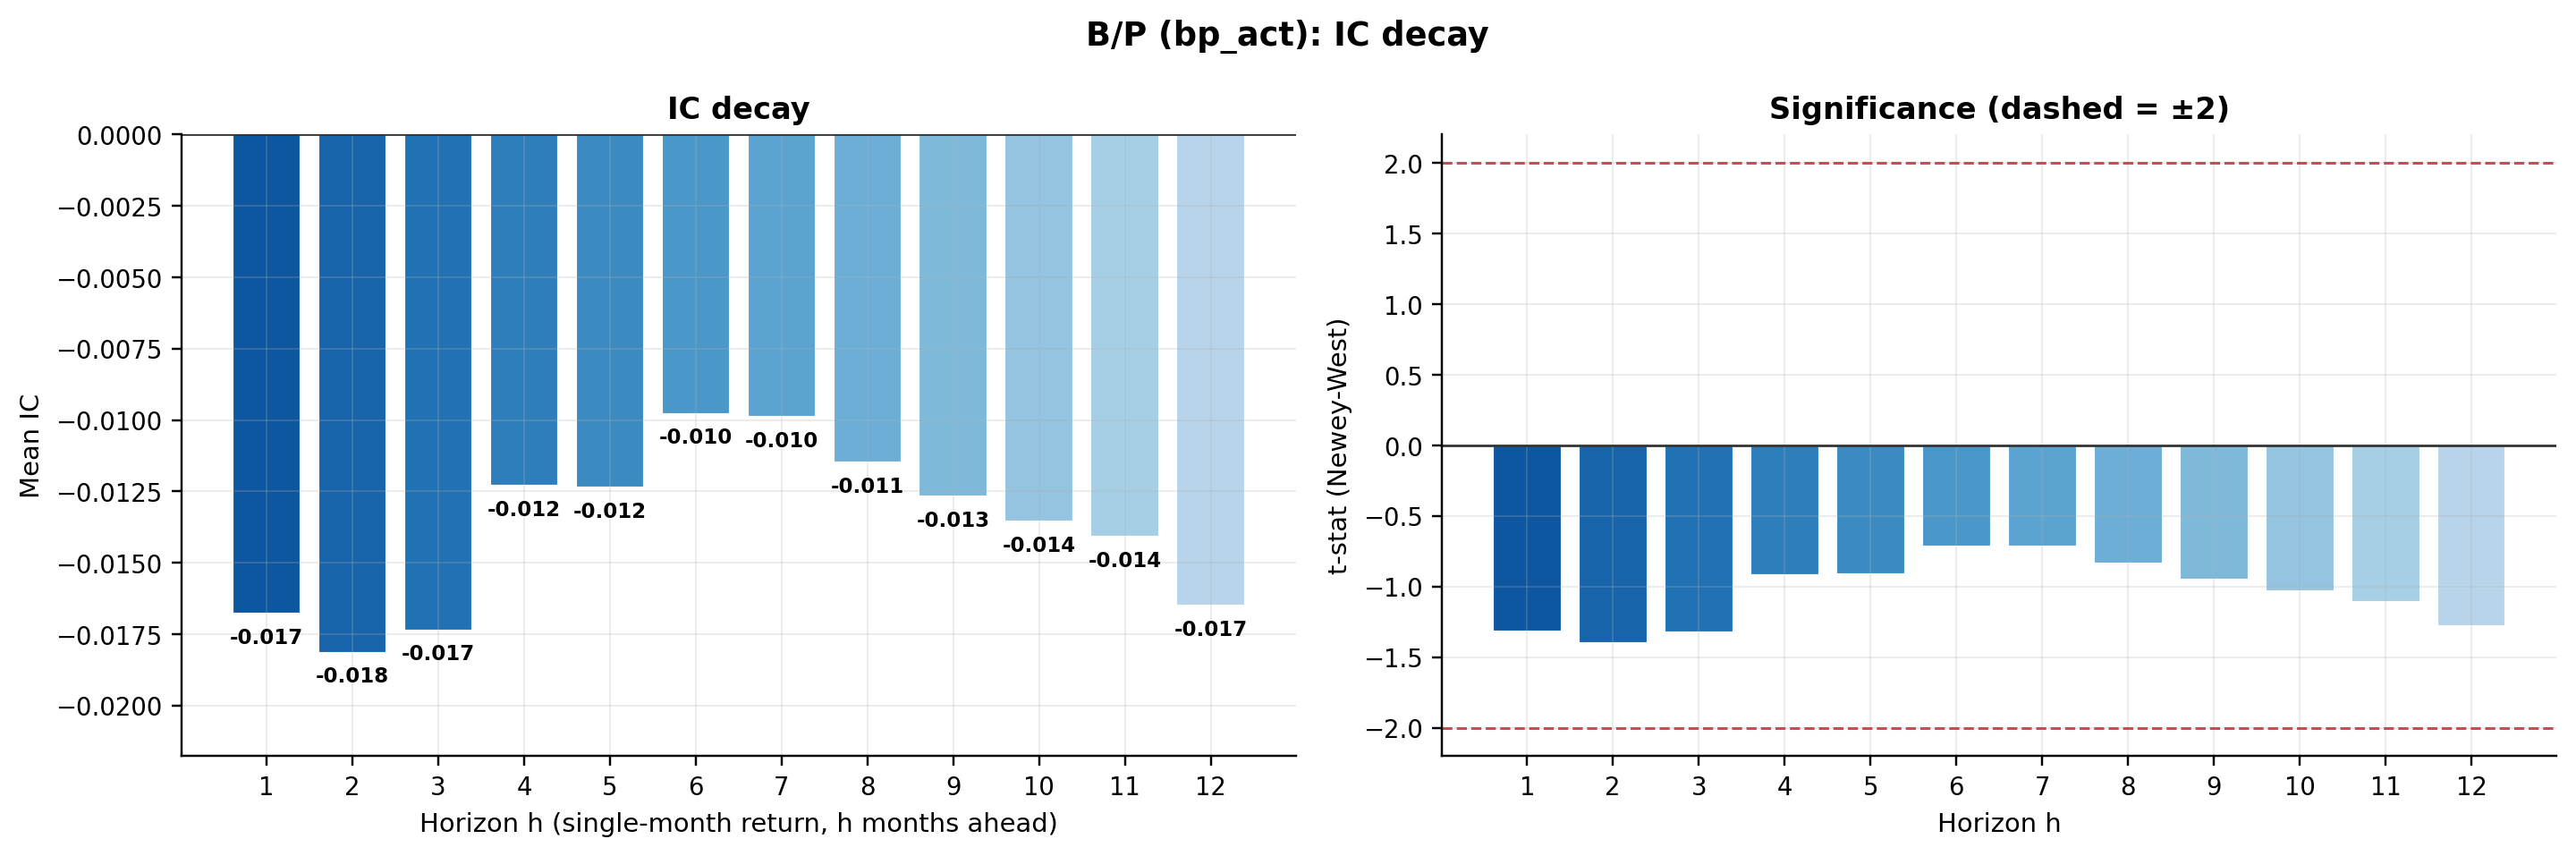

In [8]:
fig = fl.plotting.plot_ic_decay(decay, factor=FACTOR_LABEL)
fl.plotting.savefig(fig, "02_ic/11_ic_decay");

## 4. 別ファクターへの流用

IC の時系列・減衰まで 3 行で回せる。

In [9]:
def run_ic(factor: str, method: str = "blom", horizons=HORIZONS,
           corr: str = "spearman", start: int = START, end: int = END):
    # ファクター名だけで IC 時系列と減衰まで実行して (ic, ic_summary, decay) を返す
    p = fl.data.build_panel([factor], start=start, end=end)
    p = fl.preprocess.standardize_panel(p, factor, method=method)
    p = fl.data.add_forward_returns(p, horizons)
    score = f"{factor}_{method}"
    ic = fl.ic.information_coefficient(p, score, "fwd_rtn", method=corr)
    _, dec = fl.ic.ic_decay(p, score, horizons=horizons, method=corr)
    return ic, fl.ic.ic_summary(ic), dec


ic_mom, s_mom, decay_mom = run_ic("mom12_1")
s_mom.to_frame("Momentum (mom12_1)").T

,n_months,mean_IC,std_IC,ICIR,ICIR_ann,t_stat,t_stat_NW,hit_ratio,autocorr_1
Momentum (mom12_1),234.0000,0.0550,0.1826,0.3009,1.0425,4.6034,4.5621,0.6368,0.0035


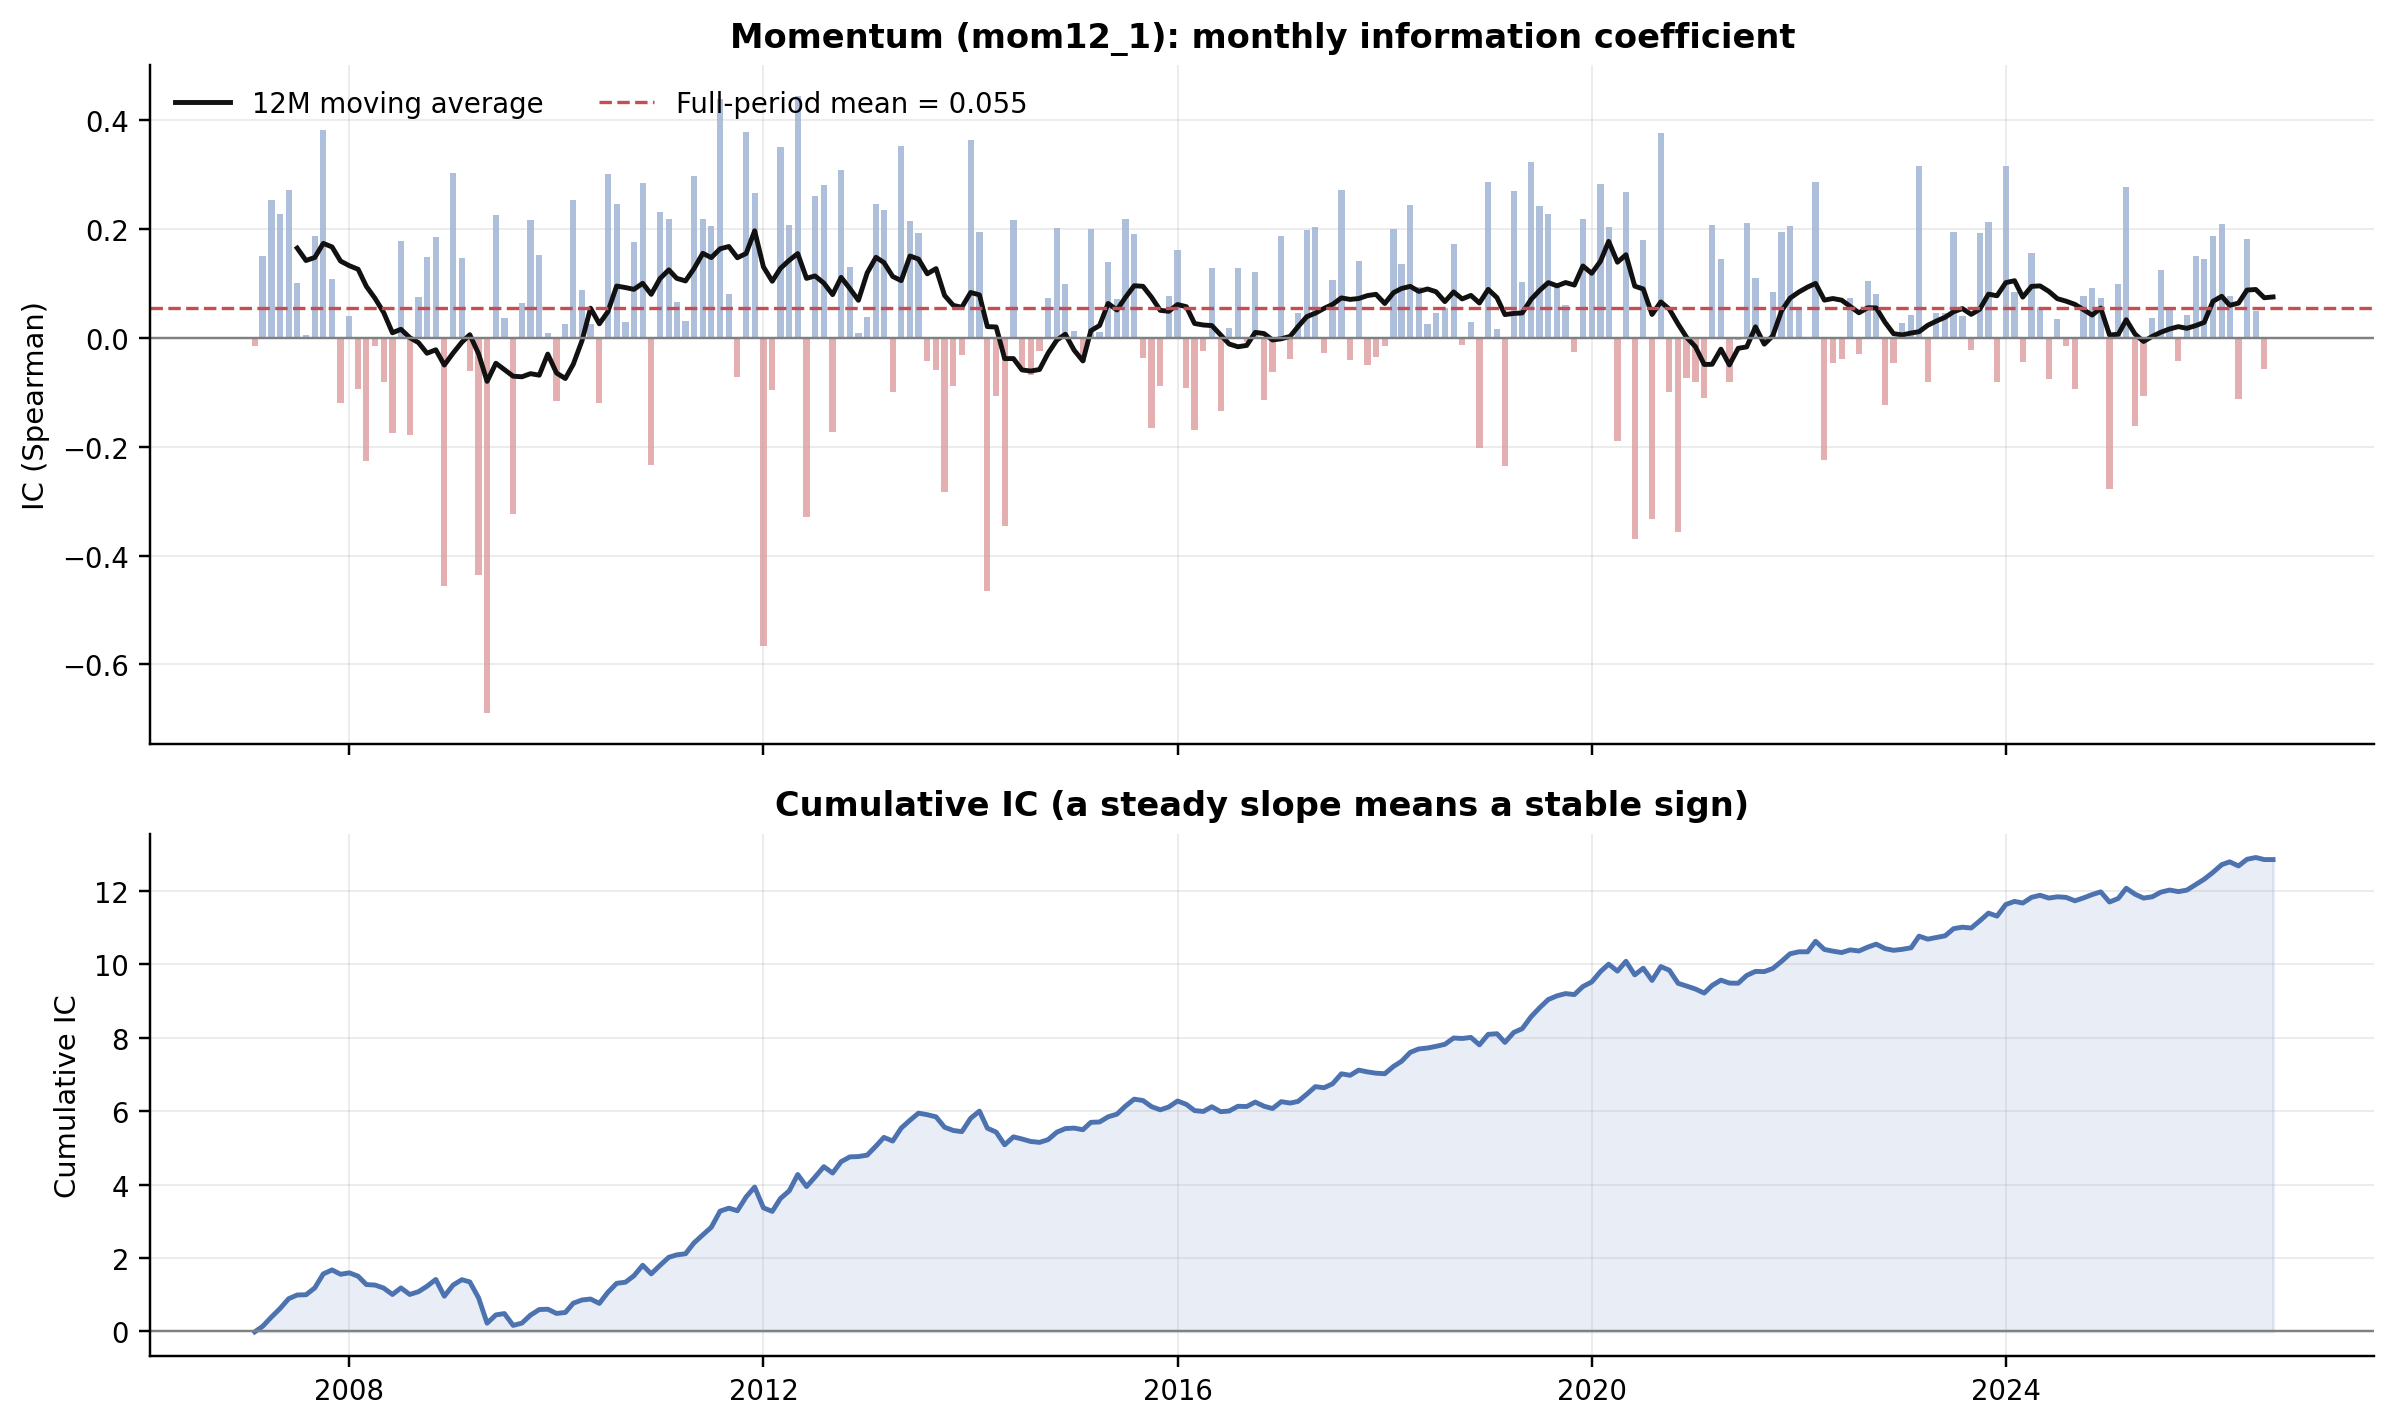

In [10]:
fig = fl.plotting.plot_ic(ic_mom, ma_window=MA_WINDOW, factor="Momentum (mom12_1)", method="Spearman")
fl.plotting.savefig(fig, "02_ic/12_ic_timeseries_momentum");

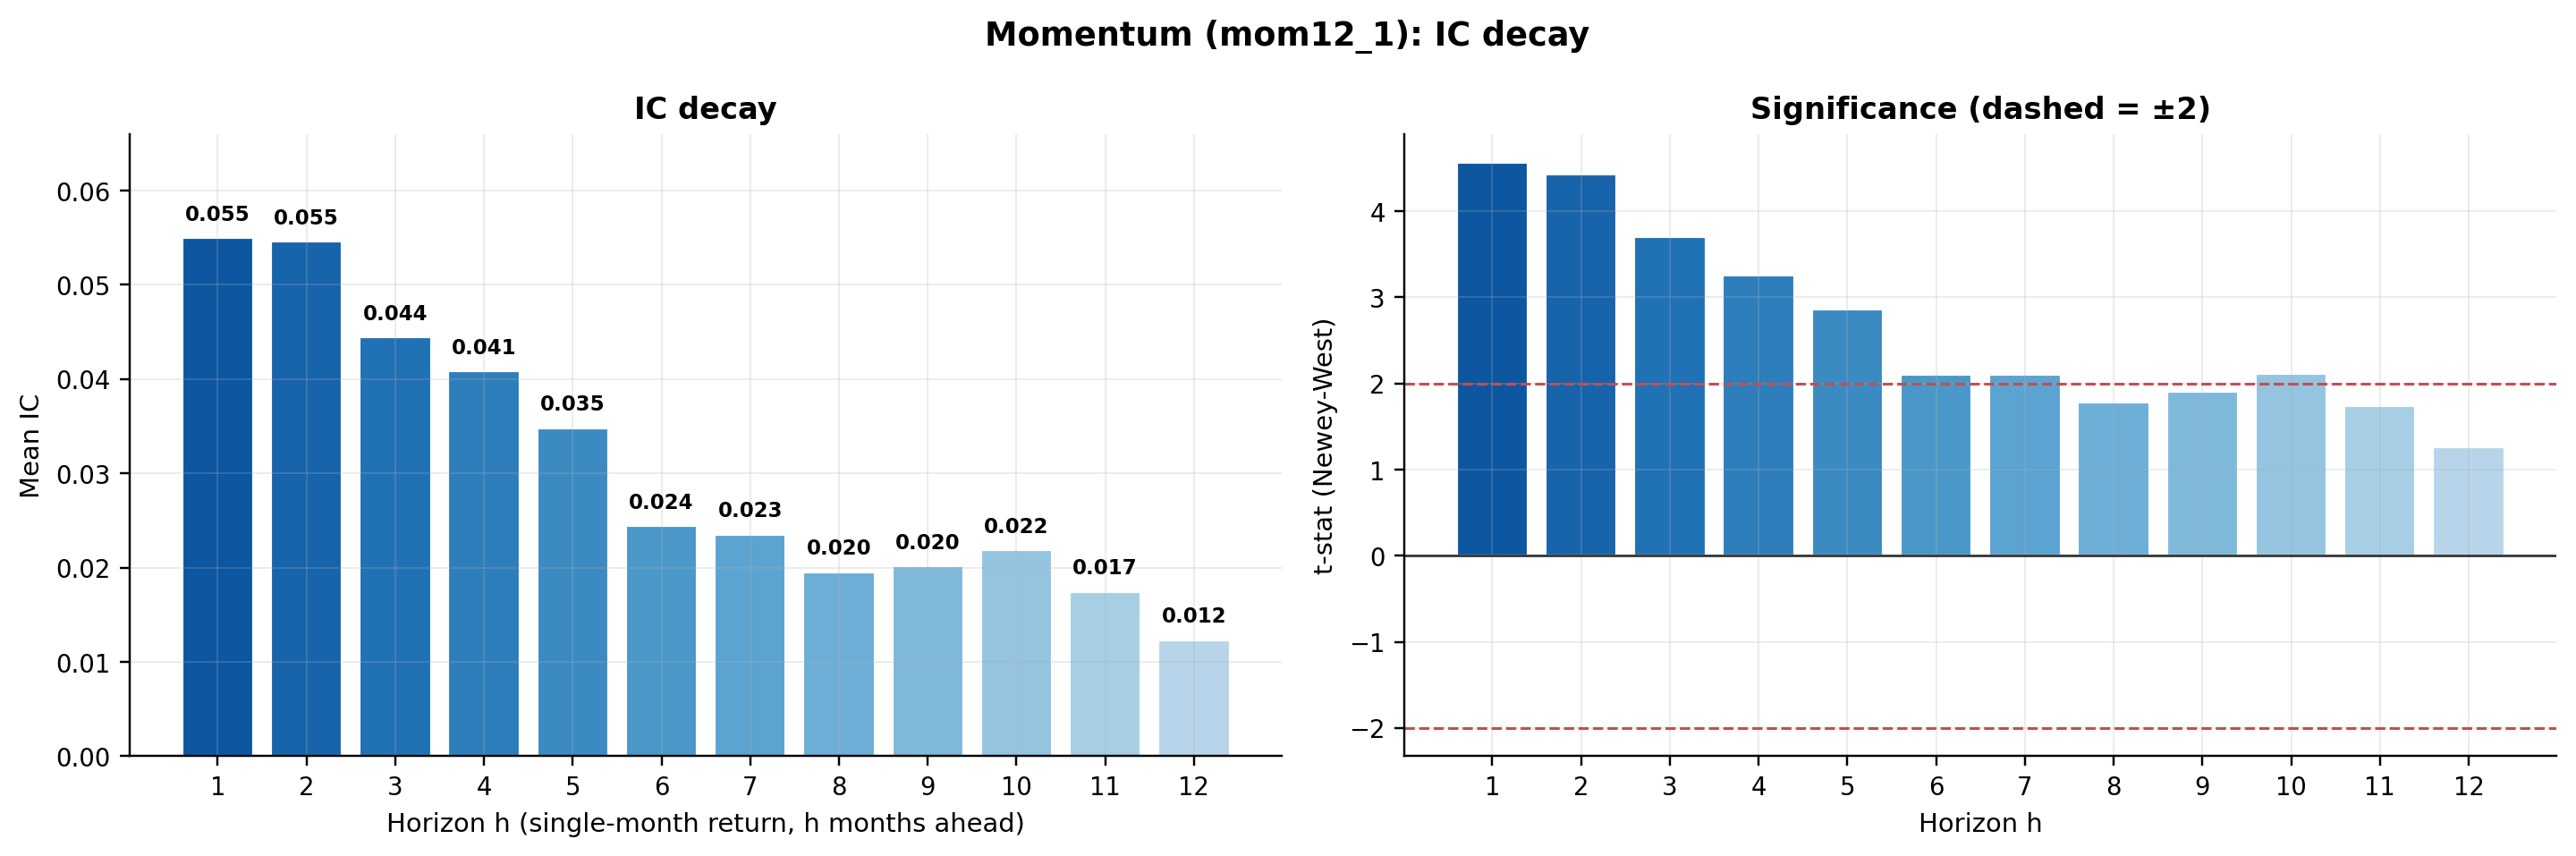

In [11]:
fig = fl.plotting.plot_ic_decay(decay_mom, factor="Momentum (mom12_1)")
fl.plotting.savefig(fig, "02_ic/13_ic_decay_momentum");

---

## 次のステップ（Step 3）

**ファクターリターン**: 翌月リターンをファクター1本に回帰した傾き $f_t$ の累積

$$r_{i,t \to t+1} = a_t + f_t\, x_{i,t} + u_{i,t}$$

実装は `src/factorlab/regression.py`（`factor_return` / `factor_return_summary`）に用意済み。